In [111]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import re
from textblob import TextBlob
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVR
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import string
import pickle


## Importing dataset 

In [89]:
df = pd.read_csv('CyberbullyingDatasets.csv')

## Analysis of data and Preprocessing

In [67]:
df.head()

,S/No,Text,English Meaning,Severe Class
0,1.0,hurl at dissenting voices,hurl at dissenting voices,Mild
1,2.0,leaders are just to selfish,leaders are just to selfish,Mild
2,3.0,they call nigeria a zoo,they call nigeria a zoo,Mild
3,4.0,make baseless assumptions and conclusions,make baseless assumptions and conclusions,Mild
4,5.0,haters picked it,haters picked it,Mild


In [68]:
df.shape

(3712, 4)

## Handling Null Values

In [69]:
df.isnull().sum()

S/No                5
Text                5
English Meaning    12
Severe Class        5
dtype: int64

In [90]:
df=df.dropna()

In [71]:
df.isnull().sum()

S/No               0
Text               0
English Meaning    0
Severe Class       0
dtype: int64

## Handling Duplicate Values

In [72]:
df.duplicated().sum()

np.int64(0)

## Distribution of Dataset

In [73]:
df['Severe Class'].value_counts()

Severe Class
Moderate       1278
Severe         1253
Mild           1083
Very Severe      86
Name: count, dtype: int64

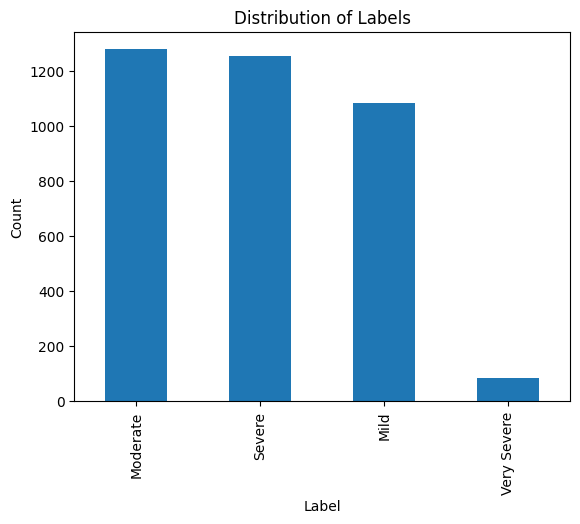

In [14]:
df['Severe Class'].value_counts().plot(kind='bar')
plt.xlabel('Label') 
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.show()

# Preprocessing

## Function to handle slang words

In [91]:
chat_words = {
    
    "u": "you",
    "ur": "your",
    "r": "are",
    "btw": "by the way",
    "idk": "i do not know",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "lol": "laughing out loud",
    "lmao": "laughing my ass off",
    "rofl": "rolling on floor laughing",
    "omg": "oh my god",
    "omw": "on my way",
    "brb": "be right back",
    "bbl": "be back later",
    "ttyl": "talk to you later",
    "gtg": "got to go",
    "gr8": "great",
    "b4": "before",
    "2day": "today",
    "2moro": "tomorrow",
    "luv": "love",
    "k": "okay",
    "kk": "okay",
    "okie": "okay",
    "pls": "please",
    "plz": "please",
    "thx": "thanks",
    "ty": "thank you",
    "np": "no problem",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "fomo": "fear of missing out",
    "bae": "before anyone else",
    "lit": "amazing",
    "salty": "angry or bitter",
    "sus": "suspicious",
    "dm": "direct message",
    "rn": "right now",
    "af": "as f***",
    "ikr": "i know right",
    "yolo": "you only live once",
    "ftw": "for the win",
    "idc": "i do not care",
    "wyd": "what are you doing",
    "wya": "where you at",
    "hbu": "how about you",
    "afaik": "as far as i know",
    "tldr": "too long didn't read",

    "fr": "for real",
    "ngl": "not gonna lie",
    "fs": "for sure",
    "dead": "very funny / shocked",
    "no cap": "no lie",
    "cap": "lie",
    "lowkey": "slightly",
    "highkey": "obviously",
    "vibes": "feelings / mood",
    "mood": "relatable feeling",
    "slay": "doing great",
    "fire": "excellent",
    "mid": "average / bad",
    "hits different": "feels unique",

   
    "cuz": "because",
    "coz": "because",
    "bc": "because",
    "bcz": "because",
    "pls": "please",
    "plz": "please",
    "msg": "message",
    "txt": "text",
    "grl": "girl",
    "boi": "boy",

   
    "gg": "good game",
    "wp": "well played",
    "noob": "beginner",
    "afk": "away from keyboard",
    "ppl": "people",
    "ez": "easy",
    "nerf": "weaken",
    "buff": "strengthen",

    "i cant": "i cannot",
    "cant take it": "cannot handle situation",
    "done": "mentally exhausted",
    "broken": "emotionally hurt",
    "helpless": "feeling helpless",
}

def chat_words_analysis(text):
    new_text = []
    for w in text.split():
        if w in chat_words:
            new_text.append(chat_words[w])
        else:
            new_text.append(w)
    return ' '.join(new_text)

## Function to clean text

In [92]:
def clean_text(text):
    try:
        text = str(text)
        

        # Converting to lowercase
        text = text.lower() 

        # Removing URLS
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Removing HTML tags
        text = re.sub(r'<.*?>', '', text)

        # Removing Punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))

        # Chat Words Treatment 
        text = chat_words_analysis(text)
        return text
    except: 
        return ""
    

## MErging classes

In [93]:
def merge_classes(label):
    if label == "Mild":
        return "Mild"
    elif label == "Moderate":
        return "Moderate"
    elif label in ["Severe", "Very Severe"]:
        return "High Risk"

df["Severe Class"] = df["Severe Class"].apply(merge_classes)

In [88]:
print(df["Severe Class"].value_counts())

Severe Class
High Risk    1339
Moderate     1278
Mild         1083
Name: count, dtype: int64


## Separation of dependent and independent variables

In [94]:
x = df['Text']
y = df['Severe Class']

## Encoding 

In [95]:
le = LabelEncoder()
y = le.fit_transform(y)

## Train Test Splitting

In [96]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state=42,stratify=y)

## Vectorization

In [97]:
vec = TfidfVectorizer(
        preprocessor=clean_text,
        ngram_range=(1,2),
        max_features=15000,
        
    )
x_train_vec = vec.fit_transform(x_train)
x_test_vec = vec.transform(x_test)

## Creating Pipeline (Cleaning + Vectorzation + Training)

In [112]:
pipeline = Pipeline([(
    "tfidf" ,TfidfVectorizer(
        preprocessor=clean_text,
        ngram_range=(1,3),
        max_features=50000,
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
        
    )),
    (
    "model",SVR()
    )
])

## MOdel Training

In [113]:
pipeline.fit(x_train,y_train)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,<function cle...002F6AE32E8C0>
,tokenizer,None


## Prediction

In [114]:
y_pred = pipeline.predict(x_test)

# MOdel Evaluation

## Accuracy

In [116]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(mae)

0.682412402747865


In [115]:
accuracy_score(y_test,y_pred)

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [102]:
print(set(y))

{np.int64(0), np.int64(1), np.int64(2)}


## Classification Report

In [20]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.47      0.49      0.48       236\n           1       0.45      0.42      0.44       251\n           2       0.58      0.59      0.59       240\n           3       0.57      0.62      0.59        13\n\n    accuracy                           0.50       740\n   macro avg       0.52      0.53      0.52       740\nweighted avg       0.50      0.50      0.50       740\n'

## Confusion MAtrix

In [ ]:
pipeline.confusion_matrix(y_test,y_pred)

## Model Saving

In [ ]:
pickle.dump(pipeline,'chatSeverityModel.pkl')